In [124]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import math
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import time
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.inspection import permutation_importance
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import RocCurveDisplay
from sklearn.impute import KNNImputer


def load_data(path):
    df = pd.read_csv(path)
    return df

DATASET_LINK = "https://www.kaggle.com/datasets/raghadalharbi/breast-cancer-gene-expression-profiles-metabric/data"
df = load_data(r"datasets\METABRIC_RNA_Mutation.csv")
df.head(10)

C:\Users\rodio\AppData\Local\Temp\ipykernel_12336\472432866.py:19: DtypeWarning: Columns (0: rasgef1b_mut, 1: hras_mut, 2: smarcb1_mut, 3: siah1_mut) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path)


,patient_id,age_at_diagnosis,type_of_breast_surgery,cancer_type,cancer_type_detailed,cellularity,chemotherapy,pam50_+_claudin-low_subtype,cohort,er_status_measured_by_ihc,...,mtap_mut,ppp2cb_mut,smarcd1_mut,nras_mut,ndfip1_mut,hras_mut,prps2_mut,smarcb1_mut,stmn2_mut,siah1_mut
0,0,75.65,MASTECTOMY,Breast Cancer,Breast Invasive Ductal Carcinoma,NaN,0,claudin-low,1.0,Positve,...,0,0,0,0,0,0,0,0,0,0
1,2,43.19,BREAST CONSERVING,Breast Cancer,Breast Invasive Ductal Carcinoma,High,0,LumA,1.0,Positve,...,0,0,0,0,0,0,0,0,0,0
2,5,48.87,MASTECTOMY,Breast Cancer,Breast Invasive Ductal Carcinoma,High,1,LumB,1.0,Positve,...,0,0,0,0,0,0,0,0,0,0
3,6,47.68,MASTECTOMY,Breast Cancer,Breast Mixed Ductal and Lobular Carcinoma,Moderate,1,LumB,1.0,Positve,...,0,0,0,0,0,0,0,0,0,0
4,8,76.97,MASTECTOMY,Breast Cancer,Breast Mixed Ductal and Lobular Carcinoma,High,1,LumB,1.0,Positve,...,0,0,0,0,0,0,0,0,0,0
5,10,78.77,MASTECTOMY,Breast Cancer,Breast Invasive Ductal Carcinoma,Moderate,0,LumB,1.0,Positve,...,0,0,0,0,0,0,0,0,0,0
6,14,56.45,BREAST CONSERVING,Breast Cancer,Breast Invasive Ductal Carcinoma,Moderate,1,LumB,1.0,Positve,...,0,0,0,0,0,0,0,0,0,0
7,22,89.08,BREAST CONSERVING,Breast Cancer,Breast Mixed Ductal and Lobular Carcinoma,Moderate,0,claudin-low,1.0,Positve,...,0,0,0,0,0,0,0,0,0,0
8,28,86.41,BREAST CONSERVING,Breast Cancer,Breast Invasive Ductal Carcinoma,Moderate,0,LumB,1.0,Positve,...,0,0,0,0,0,0,0,0,0,0
9,35,84.22,MASTECTOMY,Breast Cancer,Breast Invasive Lobular Carcinoma,High,0,Her2,1.0,Negative,...,0,0,0,0,0,0,0,0,0,0


In [125]:
df.shape

(1904, 693)

In [126]:
df.describe()

,patient_id,age_at_diagnosis,chemotherapy,cohort,neoplasm_histologic_grade,hormone_therapy,lymph_nodes_examined_positive,mutation_count,nottingham_prognostic_index,overall_survival_months,...,srd5a1,srd5a2,srd5a3,st7,star,tnk2,tulp4,ugt2b15,ugt2b17,ugt2b7
count,1904.000000,1904.000000,1904.000000,1904.000000,1832.000000,1904.000000,1904.000000,1859.000000,1904.000000,1904.000000,...,1.904000e+03,1.904000e+03,1.904000e+03,1.904000e+03,1904.000000,1.904000e+03,1.904000e+03,1.904000e+03,1904.000000,1.904000e+03
mean,3921.982143,61.087054,0.207983,2.643908,2.415939,0.616597,2.002101,5.697687,4.033019,125.121324,...,4.726891e-07,-3.676471e-07,-9.453782e-07,-1.050420e-07,-0.000002,3.676471e-07,4.726891e-07,7.878151e-07,0.000000,3.731842e-18
std,2358.478332,12.978711,0.405971,1.228615,0.650612,0.486343,4.079993,4.058778,1.144492,76.334148,...,1.000263e+00,1.000262e+00,1.000262e+00,1.000263e+00,1.000262,1.000264e+00,1.000262e+00,1.000263e+00,1.000262,1.000262e+00
min,0.000000,21.930000,0.000000,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000,...,-2.120800e+00,-3.364800e+00,-2.719400e+00,-4.982700e+00,-2.981700,-3.833300e+00,-3.609300e+00,-1.166900e+00,-2.112600,-1.051600e+00
25%,896.500000,51.375000,0.000000,1.000000,2.000000,0.000000,0.000000,3.000000,3.046000,60.825000,...,-6.188500e-01,-6.104750e-01,-6.741750e-01,-6.136750e-01,-0.632900,-6.664750e-01,-7.102000e-01,-5.058250e-01,-0.476200,-7.260000e-01
50%,4730.500000,61.770000,0.000000,3.000000,3.000000,1.000000,0.000000,5.000000,4.042000,115.616667,...,-2.456500e-01,-4.690000e-02,-1.422500e-01,-5.175000e-02,-0.026650,7.000000e-04,-2.980000e-02,-2.885500e-01,-0.133400,-4.248000e-01
75%,5536.250000,70.592500,0.000000,3.000000,3.000000,1.000000,2.000000,7.000000,5.040250,184.716667,...,3.306000e-01,5.144500e-01,5.146000e-01,5.787750e-01,0.590350,6.429000e-01,5.957250e-01,6.022500e-02,0.270375,4.284000e-01
max,7299.000000,96.290000,1.000000,5.000000,3.000000,1.000000,45.000000,80.000000,6.360000,355.200000,...,6.534900e+00,1.027030e+01,6.329000e+00,4.571300e+00,12.742300,3.938800e+00,3.833400e+00,1.088490e+01,12.643900,3.284400e+00


In [127]:
df.isnull().sum().sort_values(ascending=False)

tumor_stage                  501
3-gene_classifier_subtype    204
primary_tumor_laterality     106
neoplasm_histologic_grade     72
cellularity                   54
                            ... 
hras_mut                       0
prps2_mut                      0
smarcb1_mut                    0
stmn2_mut                      0
cancer_type                    0
Length: 693, dtype: int64

In [128]:
df.nunique()

patient_id                1904
age_at_diagnosis          1572
type_of_breast_surgery       2
cancer_type                  2
cancer_type_detailed         6
                          ... 
hras_mut                     4
prps2_mut                    3
smarcb1_mut                  4
stmn2_mut                    3
siah1_mut                    3
Length: 693, dtype: int64

In [129]:
genes = ['brca1', 'brca2', 'palb2', 'pten', 'tp53', 'atm', 'cdh1', 'chek2', 'nbn', 'nf1', 'stk11', 'bard1', 'mlh1', 'msh2', 'msh6', 'pms2', 'epcam', 'rad51c', 'rad51d', 'rad50', 'rb1', 'rbl1', 'rbl2', 'ccna1', 'ccnb1', 'cdk1', 'ccne1', 'cdk2', 'cdc25a', 'ccnd1', 'cdk4', 'cdk6', 'ccnd2', 'cdkn2a', 'cdkn2b', 'myc', 'cdkn1a', 'cdkn1b', 'e2f1', 'e2f2', 'e2f3', 'e2f4', 'e2f5', 'e2f6', 'e2f7', 'e2f8', 'src', 'jak1', 'jak2', 'stat1', 'stat2', 'stat3', 'stat5a', 'stat5b', 'mdm2', 'tp53bp1', 'adam10', 'adam17', 'aph1a', 'aph1b', 'arrdc1', 'cir1', 'ctbp1', 'ctbp2', 'cul1', 'dll1', 'dll3', 'dll4', 'dtx1', 'dtx2', 'dtx3', 'dtx4', 'ep300', 'fbxw7', 'hdac1', 'hdac2', 'hes1', 'hes5', 'heyl', 'itch', 'jag1', 'jag2', 'kdm5a', 'lfng', 'maml1', 'maml2', 'maml3', 'ncor2', 'ncstn', 'notch1', 'notch2', 'notch3', 'nrarp', 'numb', 'numbl', 'psen1', 'psen2', 'psenen', 'rbpj', 'rbpjl', 'rfng', 'snw1', 'spen', 'hes2', 'hes4', 'hes7', 'hey1', 'hey2', 'acvr1', 'acvr1b', 'acvr1c', 'acvr2a', 'acvr2b', 'acvrl1', 'akt1', 'akt1s1', 'akt2', 'apaf1', 'arl11', 'atr', 'aurka', 'bad', 'bcl2', 'bcl2l1', 'bmp10', 'bmp15', 'bmp2', 'bmp3', 'bmp4', 'bmp5', 'bmp6', 'bmp7', 'bmpr1a', 'bmpr1b', 'bmpr2', 'braf', 'casp10', 'casp3', 'casp6', 'casp7', 'casp8', 'casp9', 'chek1', 'csf1', 'csf1r', 'cxcl8', 'cxcr1', 'cxcr2', 'dab2', 'diras3', 'dlec1', 'dph1', 'egfr', 'eif4e', 'eif4ebp1', 'eif5a2', 'erbb2', 'erbb3', 'erbb4', 'fas', 'fgf1', 'fgfr1', 'folr1', 'folr2', 'folr3', 'foxo1', 'foxo3', 'gdf11', 'gdf2', 'gsk3b', 'hif1a', 'hla-g', 'hras', 'igf1', 'igf1r', 'inha', 'inhba', 'inhbc', 'itgav', 'itgb3', 'izumo1r', 'kdr', 'kit', 'kras', 'map2k1', 'map2k2', 'map2k3', 'map2k4', 'map2k5', 'map3k1', 'map3k3', 'map3k4', 'map3k5', 'mapk1', 'mapk12', 'mapk14', 'mapk3', 'mapk4', 'mapk6', 'mapk7', 'mapk8', 'mapk9', 'mdc1', 'mlst8', 'mmp1', 'mmp10', 'mmp11', 'mmp12', 'mmp13', 'mmp14', 'mmp15', 'mmp16', 'mmp17', 'mmp19', 'mmp2', 'mmp21', 'mmp23b', 'mmp24', 'mmp25', 'mmp26', 'mmp27', 'mmp28', 'mmp3', 'mmp7', 'mmp9', 'mtor', 'nfkb1', 'nfkb2', 'opcml', 'pdgfa', 'pdgfb', 'pdgfra', 'pdgfrb', 'pdpk1', 'peg3', 'pik3ca', 'pik3r1', 'pik3r2', 'plagl1', 'ptk2', 'rab25', 'rad51', 'raf1', 'rassf1', 'rheb', 'rictor', 'rps6', 'rps6ka1', 'rps6ka2', 'rps6kb1', 'rps6kb2', 'rptor', 'slc19a1', 'smad1', 'smad2', 'smad3', 'smad4', 'smad5', 'smad6', 'smad7', 'smad9', 'sptbn1', 'terc', 'tert', 'tgfb1', 'tgfb2', 'tgfb3', 'tgfbr1', 'tgfbr2', 'tgfbr3', 'tsc1', 'tsc2', 'vegfa', 'vegfb', 'wfdc2', 'wwox', 'zfyve9', 'arid1a', 'arid1b', 'cbfb', 'gata3', 'kmt2c', 'kmt2d', 'myh9', 'ncor1', 'pde4dip', 'ptprd', 'ros1', 'runx1', 'tbx3', 'abcb1', 'abcb11', 'abcc1', 'abcc10', 'bbc3', 'bmf', 'cyp2c8', 'cyp3a4', 'fgf2', 'fn1', 'map2', 'map4', 'mapt', 'nr1i2', 'slco1b3', 'tubb1', 'tubb4a', 'tubb4b', 'twist1', 'adgra2', 'afdn', 'aff2', 'agmo', 'agtr2', 'ahnak', 'ahnak2', 'akap9', 'alk', 'apc', 'arid2', 'arid5b', 'asxl1', 'asxl2', 'bap1', 'bcas3', 'birc6', 'cacna2d3', 'ccnd3', 'chd1', 'clk3', 'clrn2', 'col12a1', 'col22a1', 'col6a3', 'ctcf', 'ctnna1', 'ctnna3', 'dnah11', 'dnah2', 'dnah5', 'dtwd2', 'fam20c', 'fanca', 'fancd2', 'flt3', 'foxp1', 'frmd3', 'gh1', 'gldc', 'gpr32', 'gps2', 'hdac9', 'herc2', 'hist1h2bc', 'kdm3a', 'kdm6a', 'klrg1', 'l1cam', 'lama2', 'lamb3', 'large1', 'ldlrap1', 'lifr', 'lipi', 'magea8', 'map3k10', 'map3k13', 'men1', 'mtap', 'muc16', 'myo1a', 'myo3a', 'ncoa3', 'nek1', 'nf2', 'npnt', 'nr2f1', 'nr3c1', 'nras', 'nrg3', 'nt5e', 'or6a2', 'palld', 'pbrm1', 'ppp2cb', 'ppp2r2a', 'prkacg', 'prkce', 'prkcq', 'prkcz', 'prkg1', 'prps2', 'prr16', 'ptpn22', 'ptprm', 'rasgef1b', 'rpgr', 'ryr2', 'sbno1', 'setd1a', 'setd2', 'setdb1', 'sf3b1', 'sgcd', 'shank2', 'siah1', 'sik1', 'sik2', 'smarcb1', 'smarcc1', 'smarcc2', 'smarcd1', 'spaca1', 'stab2', 'stmn2', 'syne1', 'taf1', 'taf4b', 'tbl1xr1', 'tg', 'thada', 'thsd7a', 'ttyh1', 'ubr5', 'ush2a', 'usp9x', 'utrn', 'zfp36l1', 'ackr3', 'akr1c1', 'akr1c2', 'akr1c3', 'akr1c4', 'akt3', 'ar', 'bche', 'cdk8', 'cdkn2c', 'cyb5a', 'cyp11a1', 'cyp11b2', 'cyp17a1', 'cyp19a1', 'cyp21a2', 'cyp3a43', 'cyp3a5', 'cyp3a7', 'ddc', 'hes6', 'hsd17b1', 'hsd17b10', 'hsd17b11', 'hsd17b12', 'hsd17b13', 'hsd17b14', 'hsd17b2', 'hsd17b3', 'hsd17b4', 'hsd17b6', 'hsd17b7', 'hsd17b8', 'hsd3b1', 'hsd3b2', 'hsd3b7', 'mecom', 'met', 'ncoa2', 'nrip1', 'pik3r3', 'prkci', 'prkd1', 'ran', 'rdh5', 'sdc4', 'serpini1', 'shbg', 'slc29a1', 'sox9', 'spry2', 'srd5a1', 'srd5a2', 'srd5a3', 'st7', 'star', 'tnk2', 'tulp4', 'ugt2b15', 'ugt2b17', 'ugt2b7']

In [130]:
mutations = ['pik3ca_mut', 'tp53_mut', 'muc16_mut', 'ahnak2_mut', 'kmt2c_mut', 'syne1_mut', 'gata3_mut', 'map3k1_mut', 'ahnak_mut', 'dnah11_mut', 'cdh1_mut', 'dnah2_mut', 'kmt2d_mut', 'ush2a_mut', 'ryr2_mut', 'dnah5_mut', 'herc2_mut', 'pde4dip_mut', 'akap9_mut', 'tg_mut', 'birc6_mut', 'utrn_mut', 'tbx3_mut', 'col6a3_mut', 'arid1a_mut', 'lama2_mut', 'notch1_mut', 'cbfb_mut', 'ncor2_mut', 'col12a1_mut', 'col22a1_mut', 'pten_mut', 'akt1_mut', 'atr_mut', 'thada_mut', 'ncor1_mut', 'stab2_mut', 'myh9_mut', 'runx1_mut', 'nf1_mut', 'map2k4_mut', 'ros1_mut', 'lamb3_mut', 'arid1b_mut', 'erbb2_mut', 'sf3b1_mut', 'shank2_mut', 'ep300_mut', 'ptprd_mut', 'usp9x_mut', 'setd2_mut', 'setd1a_mut', 'thsd7a_mut', 'afdn_mut', 'erbb3_mut', 'rb1_mut', 'myo1a_mut', 'alk_mut', 'fanca_mut', 'adgra2_mut', 'ubr5_mut', 'pik3r1_mut', 'myo3a_mut', 'asxl2_mut', 'apc_mut', 'ctcf_mut', 'asxl1_mut', 'fancd2_mut', 'taf1_mut', 'kdm6a_mut', 'ctnna3_mut', 'brca1_mut', 'ptprm_mut', 'foxo3_mut', 'usp28_mut', 'gldc_mut', 'brca2_mut', 'cacna2d3_mut', 'arid2_mut', 'aff2_mut', 'lifr_mut', 'sbno1_mut', 'kdm3a_mut', 'ncoa3_mut', 'bap1_mut', 'l1cam_mut', 'pbrm1_mut', 'chd1_mut', 'jak1_mut', 'setdb1_mut', 'fam20c_mut', 'arid5b_mut', 'egfr_mut', 'map3k10_mut', 'smarcc2_mut', 'erbb4_mut', 'npnt_mut', 'nek1_mut', 'agmo_mut', 'zfp36l1_mut', 'smad4_mut', 'sik1_mut', 'casp8_mut', 'prkcq_mut', 'smarcc1_mut', 'palld_mut', 'dcaf4l2_mut', 'bcas3_mut', 'cdkn1b_mut', 'gps2_mut', 'men1_mut', 'stk11_mut', 'sik2_mut', 'ptpn22_mut', 'brip1_mut', 'flt3_mut', 'nrg3_mut', 'fbxw7_mut', 'ttyh1_mut', 'taf4b_mut', 'or6a2_mut', 'map3k13_mut', 'hdac9_mut', 'prkacg_mut', 'rpgr_mut', 'large1_mut', 'foxp1_mut', 'clk3_mut', 'prkcz_mut', 'lipi_mut', 'ppp2r2a_mut', 'prkce_mut', 'gh1_mut', 'gpr32_mut', 'kras_mut', 'nf2_mut', 'chek2_mut', 'ldlrap1_mut', 'clrn2_mut', 'acvrl1_mut', 'agtr2_mut', 'cdkn2a_mut', 'ctnna1_mut', 'magea8_mut', 'prr16_mut', 'dtwd2_mut', 'akt2_mut', 'braf_mut', 'foxo1_mut', 'nt5e_mut', 'ccnd3_mut', 'nr3c1_mut', 'prkg1_mut', 'tbl1xr1_mut', 'frmd3_mut', 'smad2_mut', 'sgcd_mut', 'spaca1_mut', 'rasgef1b_mut', 'hist1h2bc_mut', 'nr2f1_mut', 'klrg1_mut', 'mbl2_mut', 'mtap_mut', 'ppp2cb_mut', 'smarcd1_mut', 'nras_mut', 'ndfip1_mut', 'hras_mut', 'prps2_mut', 'smarcb1_mut', 'stmn2_mut', 'siah1_mut']

### ER-Status Prediction on Gene Expression

In [131]:
df["er_status"] = df["er_status"].map({"Negative": 0, "Positive": 1})

In [132]:
df["er_status"].value_counts(normalize=True)

er_status
1    0.766282
0    0.233718
Name: proportion, dtype: float64

In [133]:
train_set, test_set = train_test_split(df, test_size=0.2)
X_train = train_set[genes].drop(columns=["gata3", "mapt", "bcl2"])
y_train = train_set["er_status"]
X_test = test_set[genes].drop(columns=["gata3", "mapt", "bcl2"])
y_test = test_set["er_status"]
X_train.head(10)

,brca1,brca2,palb2,pten,tp53,atm,cdh1,chek2,nbn,nf1,...,srd5a1,srd5a2,srd5a3,st7,star,tnk2,tulp4,ugt2b15,ugt2b17,ugt2b7
648,0.1981,0.3484,-1.1509,-0.1224,-0.1633,-0.0027,1.8878,-0.3341,0.1003,0.1534,...,-0.8784,-0.6469,0.8639,0.0092,0.2225,0.5397,-0.9151,0.8324,-0.3564,-0.6252
1124,1.1197,1.8152,-0.6756,0.0301,-0.4154,0.4349,0.8765,-0.1043,0.4411,-0.0739,...,-1.3025,0.0275,0.1393,-0.1947,-0.0973,1.1355,0.0053,-0.2878,0.8131,-0.6819
1070,1.4055,-0.7108,0.1382,-1.3895,-1.2188,-1.6878,-0.7060,1.1265,0.1389,0.2179,...,-1.2360,0.2365,-1.0600,-0.4937,-0.3137,3.1363,2.7235,-0.3091,-0.0989,0.0222
171,-1.1296,-1.0530,-0.1970,1.0955,-1.8165,-0.2869,-2.0776,-0.9481,-0.0152,-1.4826,...,-0.6548,0.2604,-0.1752,0.3098,0.9665,-1.2335,-0.1939,-0.1737,-0.5359,0.1020
882,-1.3031,1.0916,-0.7779,0.5697,0.0828,-0.8696,0.7393,0.1884,0.0553,1.0008,...,0.7603,-2.1694,-0.0361,-0.5602,-0.3130,-0.0905,0.2523,-0.6508,0.1365,-0.8167
1203,-1.1627,-0.1259,1.4869,-0.5958,-1.4671,1.7159,-0.4436,1.0359,0.8789,-0.3435,...,1.1764,0.7794,0.1235,-0.8915,-0.9333,-0.3960,0.2205,-0.4132,0.2281,-0.5220
689,3.5979,1.3148,-0.5575,-1.1281,2.4120,0.2607,0.5386,1.6964,0.1930,0.5873,...,-0.2073,0.1596,-0.0785,0.1165,1.3242,-1.4402,-0.8675,-0.8353,-0.0231,-0.7484
1893,0.4984,-0.6441,-0.4191,0.7767,-0.1300,0.9972,0.6977,-1.6772,-1.1119,-0.1797,...,-0.3262,0.7857,3.1043,0.9358,-0.9700,-1.6256,-0.2487,-0.7036,-0.1714,0.7972
473,-0.5108,0.5947,-0.4528,0.6045,0.4147,0.4137,0.0022,0.1169,0.8355,-0.6843,...,-0.7872,-0.7226,-0.4155,-0.4446,-0.0576,-0.5012,-0.1199,-0.3983,1.3612,-0.6979
1332,-0.2115,0.5151,-0.1959,0.3074,0.8092,0.1425,-0.8722,-0.9293,-0.4777,1.1916,...,-0.1539,-0.9089,-1.0097,-1.5053,-0.4114,0.4356,0.3191,-0.6768,-0.3997,-0.8506


In [134]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=100, random_state=42)
}

metrics_report = []

for model_name, model in models.items():
    start_time = time.time()
    
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    
    train_time = time.time() - start_time
    
    metrics_report.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision (CT)": precision_score(y_test, y_pred),
        "Recall (CT)": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "ROC AUC": roc_auc_score(y_test, y_prob),
        "Time (sec)": round(train_time, 2)
    })

report_df = pd.DataFrame(metrics_report)

report_df = report_df.sort_values(by="ROC AUC", ascending=False).reset_index(drop=True)

print(report_df.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

              Model  Accuracy  Precision (CT)  Recall (CT)  F1 Score  ROC AUC  Time (sec)
  Gradient Boosting    0.9580          0.9785       0.9647    0.9715   0.9823     14.1000
Logistic Regression    0.9423          0.9745       0.9470    0.9606   0.9802      0.0500
      Random Forest    0.9396          0.9545       0.9647    0.9596   0.9791      0.3500


In [135]:
importances = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': models["Gradient Boosting"].feature_importances_
})

importances = importances.sort_values(by='Importance', ascending=False)
importances.head(10)

,Feature,Importance
173,igf1r,0.416119
431,ar,0.153995
151,egfr,0.089780
132,bmpr1b,0.046502
454,hsd17b4,0.029475
89,notch1,0.024484
26,ccne1,0.018711
287,tbx3,0.016641
31,cdk6,0.015362
476,srd5a1,0.011773


In [136]:
train_set, test_set = train_test_split(df, test_size=0.2)
X_train = train_set[genes]
y_train = train_set["er_status"]
X_test = test_set[genes]
y_test = test_set["er_status"]
X_train.head(10)

,brca1,brca2,palb2,pten,tp53,atm,cdh1,chek2,nbn,nf1,...,srd5a1,srd5a2,srd5a3,st7,star,tnk2,tulp4,ugt2b15,ugt2b17,ugt2b7
1826,-1.0881,1.0096,1.0185,0.1199,1.8483,0.3580,0.4438,-0.4160,0.1590,-0.4103,...,0.2707,-0.9175,-0.0275,0.8306,0.9031,-1.2561,-0.8827,-0.3978,-0.4039,-0.5543
925,-0.3361,0.6936,0.7544,1.0900,-1.1583,0.3075,0.4725,-0.6872,-0.3637,0.9254,...,2.4758,0.1286,0.1060,-1.1419,0.0578,0.7571,-0.7090,-0.5864,-0.0671,-0.4158
392,-1.0529,0.3424,-0.6861,1.0360,-0.6966,1.1563,0.1979,0.1406,-0.3514,-0.9613,...,-1.0111,-0.0219,-0.8170,-0.2323,-1.2193,0.0988,-1.5777,0.3522,-0.4319,-0.6707
717,-0.4706,0.7686,-1.3717,0.5560,0.0434,1.2479,0.6992,0.6519,1.4305,-0.5728,...,-0.2333,0.1638,-0.0456,0.6242,0.9094,-0.7783,-0.0425,0.9146,0.7018,-0.1465
1303,0.1978,-0.1756,-0.2156,1.0431,0.9060,2.9113,0.4828,1.1710,-0.4475,0.0679,...,-0.7101,0.8883,0.1816,0.7031,1.6782,-0.0382,-0.8521,0.5310,-0.8906,-0.7411
1472,0.5169,1.0686,-0.1380,-0.5794,2.0118,0.3114,0.0313,1.5258,1.7989,-0.7746,...,0.7322,0.9785,0.8015,1.7959,-0.9379,0.0469,-0.5551,-0.7718,1.1785,-0.8379
1466,0.2509,-1.6802,0.5632,-0.1254,0.2776,-0.9906,-0.1127,-0.5428,-0.8890,-0.4361,...,-0.4249,0.1897,0.0217,0.2784,0.0546,0.3914,0.1198,-0.0062,-0.1497,-0.5118
369,-1.0711,-0.5929,-0.3184,0.3210,-0.4898,-1.0491,0.0032,-0.2190,-0.3956,-1.3157,...,-0.8276,0.2963,-0.6090,-0.0060,-1.8365,-0.0336,-1.0220,-0.2073,-0.4730,-0.3762
39,-0.1192,0.4046,-0.5506,1.2308,0.8716,-2.7133,1.4165,-0.4067,-0.3817,-1.2187,...,-0.5558,-0.1408,0.3260,0.4235,-0.0307,-0.2652,0.1086,-0.7170,0.0638,-0.5756
1385,-0.3581,1.2725,0.2980,0.1025,1.3088,-0.1203,-2.7722,0.7457,-1.0788,0.1243,...,0.1362,-0.2107,-0.5308,-0.2211,-0.2978,0.7287,0.8341,1.0185,0.1838,1.6289


In [137]:
models2 = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=100, random_state=42)
}

metrics_report = []

for model_name, model in models2.items():
    start_time = time.time()
    
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    
    train_time = time.time() - start_time
    
    metrics_report.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision (CT)": precision_score(y_test, y_pred),
        "Recall (CT)": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "ROC AUC": roc_auc_score(y_test, y_prob),
        "Time (sec)": round(train_time, 2)
    })

report_df = pd.DataFrame(metrics_report)

report_df = report_df.sort_values(by="ROC AUC", ascending=False).reset_index(drop=True)

print(report_df.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

              Model  Accuracy  Precision (CT)  Recall (CT)  F1 Score  ROC AUC  Time (sec)
  Gradient Boosting    0.9711          0.9860       0.9758    0.9809   0.9969     14.2800
      Random Forest    0.9685          0.9792       0.9792    0.9792   0.9963      0.3300
Logistic Regression    0.9580          0.9823       0.9619    0.9720   0.9890      0.0500


In [138]:
importances = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': models2["Gradient Boosting"].feature_importances_
})

importances = importances.sort_values(by='Importance', ascending=False)
importances.head(10)

,Feature,Importance
280,gata3,0.727055
174,igf1r,0.041990
302,mapt,0.035674
122,bcl2,0.028052
26,ccne1,0.018965
350,gps2,0.009163
156,erbb2,0.009074
440,cyp11b2,0.007710
479,srd5a1,0.006039
101,snw1,0.004995


### Mortality Prediction on Gene Expression

In [139]:
df["death_from_cancer"].value_counts()

death_from_cancer
Living                  801
Died of Disease         622
Died of Other Causes    480
Name: count, dtype: int64

In [140]:
df["death_from_cancer"] = df["death_from_cancer"].map({"Living": 0, "Died of Other Causes": 0, "Died of Disease": 1})
df.head(10)

,patient_id,age_at_diagnosis,type_of_breast_surgery,cancer_type,cancer_type_detailed,cellularity,chemotherapy,pam50_+_claudin-low_subtype,cohort,er_status_measured_by_ihc,...,mtap_mut,ppp2cb_mut,smarcd1_mut,nras_mut,ndfip1_mut,hras_mut,prps2_mut,smarcb1_mut,stmn2_mut,siah1_mut
0,0,75.65,MASTECTOMY,Breast Cancer,Breast Invasive Ductal Carcinoma,NaN,0,claudin-low,1.0,Positve,...,0,0,0,0,0,0,0,0,0,0
1,2,43.19,BREAST CONSERVING,Breast Cancer,Breast Invasive Ductal Carcinoma,High,0,LumA,1.0,Positve,...,0,0,0,0,0,0,0,0,0,0
2,5,48.87,MASTECTOMY,Breast Cancer,Breast Invasive Ductal Carcinoma,High,1,LumB,1.0,Positve,...,0,0,0,0,0,0,0,0,0,0
3,6,47.68,MASTECTOMY,Breast Cancer,Breast Mixed Ductal and Lobular Carcinoma,Moderate,1,LumB,1.0,Positve,...,0,0,0,0,0,0,0,0,0,0
4,8,76.97,MASTECTOMY,Breast Cancer,Breast Mixed Ductal and Lobular Carcinoma,High,1,LumB,1.0,Positve,...,0,0,0,0,0,0,0,0,0,0
5,10,78.77,MASTECTOMY,Breast Cancer,Breast Invasive Ductal Carcinoma,Moderate,0,LumB,1.0,Positve,...,0,0,0,0,0,0,0,0,0,0
6,14,56.45,BREAST CONSERVING,Breast Cancer,Breast Invasive Ductal Carcinoma,Moderate,1,LumB,1.0,Positve,...,0,0,0,0,0,0,0,0,0,0
7,22,89.08,BREAST CONSERVING,Breast Cancer,Breast Mixed Ductal and Lobular Carcinoma,Moderate,0,claudin-low,1.0,Positve,...,0,0,0,0,0,0,0,0,0,0
8,28,86.41,BREAST CONSERVING,Breast Cancer,Breast Invasive Ductal Carcinoma,Moderate,0,LumB,1.0,Positve,...,0,0,0,0,0,0,0,0,0,0
9,35,84.22,MASTECTOMY,Breast Cancer,Breast Invasive Lobular Carcinoma,High,0,Her2,1.0,Negative,...,0,0,0,0,0,0,0,0,0,0


In [141]:
df = df.dropna(subset="death_from_cancer")

In [142]:
df["death_from_cancer"].value_counts(normalize=True)

death_from_cancer
0.0    0.673148
1.0    0.326852
Name: proportion, dtype: float64

In [143]:
train_set, test_set = train_test_split(df, test_size=0.2)
X_train = train_set[genes]
y_train = train_set["death_from_cancer"]
X_test = test_set[genes]
y_test = test_set["death_from_cancer"]
X_train.head(10)

,brca1,brca2,palb2,pten,tp53,atm,cdh1,chek2,nbn,nf1,...,srd5a1,srd5a2,srd5a3,st7,star,tnk2,tulp4,ugt2b15,ugt2b17,ugt2b7
1660,1.2428,1.3406,-0.7272,0.0149,-1.6632,-1.6306,0.0314,0.2147,0.2521,2.0679,...,-0.6021,-0.2249,0.3288,-0.2591,1.6460,0.6182,1.3993,-0.3901,0.3551,1.4625
308,-0.0270,2.7885,1.5398,-0.4376,-0.9116,-0.3164,1.0932,0.0978,0.3733,-0.2063,...,0.8418,-0.7640,-0.5041,-1.2581,0.9528,-1.0058,0.0941,-0.2464,-0.0139,-0.8095
385,1.8586,0.3759,0.0396,0.0445,-1.2649,-1.3590,0.9667,0.5432,0.4885,0.4753,...,-0.8442,-0.1212,1.8094,0.4127,0.1708,-0.9521,-0.4377,-0.4010,-0.6943,-0.7032
1001,-0.4838,0.7188,-0.3374,0.3912,0.1620,0.7860,-0.3863,-1.3066,1.6158,0.7572,...,-0.5486,0.0275,-0.3626,-0.8420,0.2299,0.2078,1.0890,-0.1511,0.1292,0.1173
760,-1.4110,0.4130,0.1954,0.5770,1.0507,2.8005,1.1377,0.5292,-0.5706,-0.3871,...,-0.3835,1.0768,0.6421,-0.0455,0.1068,-1.0622,1.2521,-0.0830,-0.2410,-0.5297
832,1.8555,2.2241,-0.3482,0.2961,-0.8830,2.1405,1.4161,-1.2594,1.4092,-0.4052,...,-0.7698,1.2771,-0.7289,-1.7880,-0.6042,0.4469,0.6372,-0.0510,0.0295,-0.8429
353,0.8865,-0.4173,-0.7044,0.0852,2.7826,0.7445,-0.3487,1.2722,-0.3447,0.1116,...,-0.6755,9.4935,0.3103,-1.0118,-0.2174,-0.6542,2.2452,-0.1678,-0.2813,-0.3478
1200,-0.1862,0.5544,-1.3670,0.0632,0.1578,1.2164,-0.4610,-1.0280,0.1775,-0.0563,...,-1.0646,0.0803,0.3977,-0.0520,-0.4647,-0.9480,-0.3541,-0.2239,-0.1003,2.6474
1635,1.9407,0.0966,0.8992,-0.8349,-1.2346,-1.2824,-0.7161,1.4751,-2.0239,1.0224,...,-0.2905,1.2433,-1.1574,-0.0828,1.7866,0.6341,1.5910,-0.2378,-0.5158,-0.0657
897,0.2886,-0.4365,0.7887,0.6470,-1.1264,1.4748,1.0701,-0.2069,-1.4822,-0.7042,...,0.5128,-0.5806,0.1577,0.1490,-0.7747,-0.3907,0.9935,-0.3565,-0.5970,-0.6774


In [144]:
death_models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=100, random_state=42)
}

metrics_report = []

for model_name, model in death_models.items():
    start_time = time.time()
    
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    
    train_time = time.time() - start_time
    
    metrics_report.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision (CT)": precision_score(y_test, y_pred),
        "Recall (CT)": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "ROC AUC": roc_auc_score(y_test, y_prob),
        "Time (sec)": round(train_time, 2)
    })

report_df = pd.DataFrame(metrics_report)

report_df = report_df.sort_values(by="ROC AUC", ascending=False).reset_index(drop=True)

print(report_df.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

              Model  Accuracy  Precision (CT)  Recall (CT)  F1 Score  ROC AUC  Time (sec)
  Gradient Boosting    0.6404          0.4808       0.1852    0.2674   0.6490     14.2500
      Random Forest    0.6457          0.5000       0.0519    0.0940   0.6202      0.3500
Logistic Regression    0.6115          0.4425       0.3704    0.4032   0.5822      0.0800


In [145]:
importances = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': death_models["Random Forest"].feature_importances_
})

importances = importances.sort_values(by='Importance', ascending=False)
importances.head(10)

,Feature,Importance
120,aurka,0.007357
39,e2f2,0.006406
26,ccne1,0.006107
52,stat5a,0.005529
122,bcl2,0.004544
230,pdgfb,0.003921
53,stat5b,0.003876
84,maml1,0.003848
210,mmp15,0.003796
61,cir1,0.003752


In [146]:

importances = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': permutation_importance(death_models["Logistic Regression"], X_train, y_train)['importances_mean']
})
importances = importances.sort_values(by='Importance', ascending=False)
importances.head(10)

,Feature,Importance
153,eif4e,0.038502
277,arid1a,0.035217
145,cxcl8,0.034691
61,cir1,0.031800
173,igf1,0.029566
230,pdgfb,0.029304
271,tsc2,0.028909
289,tbx3,0.028252
25,cdk1,0.027989
59,aph1b,0.027727


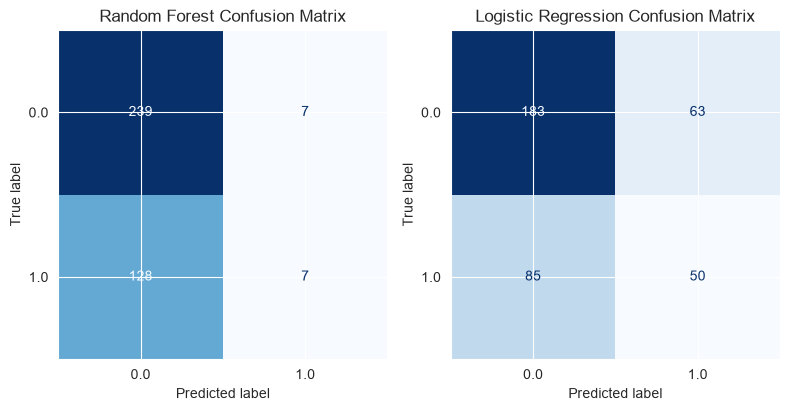

In [147]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(8, 5))
ConfusionMatrixDisplay.from_estimator(
    death_models["Random Forest"], X_test, y_test, 
    cmap=plt.cm.Blues, 
    colorbar=False,
    ax=axes[0]
)
ConfusionMatrixDisplay.from_estimator(
    death_models["Logistic Regression"], X_test, y_test, 
    cmap=plt.cm.Blues, 
    colorbar=False,
    ax=axes[1]
)
axes[0].set_title('Random Forest Confusion Matrix')
axes[1].set_title('Logistic Regression Confusion Matrix')
plt.tight_layout()
plt.show()

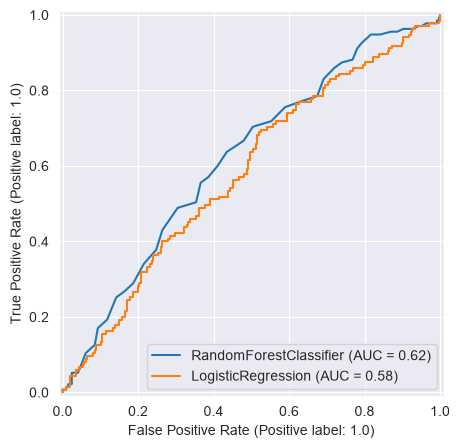

In [148]:
fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(8, 5))
RocCurveDisplay.from_estimator(death_models["Random Forest"], X_test, y_test, ax=axes)
RocCurveDisplay.from_estimator(death_models["Logistic Regression"], X_test, y_test, ax=axes)
plt.show()

### Mortality Prediction on Clinical Data

In [149]:
death_df = df.copy()
death_df["cancer_type_detailed"].value_counts()

cancer_type_detailed
Breast Invasive Ductal Carcinoma             1499
Breast Mixed Ductal and Lobular Carcinoma     207
Breast Invasive Lobular Carcinoma             142
Breast Invasive Mixed Mucinous Carcinoma       22
Breast                                         17
Metaplastic Breast Cancer                       1
Name: count, dtype: int64

In [150]:
death_df = death_df[death_df["cancer_type_detailed"] != "Metaplastic Breast Cancer"]
death_df["cellularity"].value_counts()

cellularity
High        939
Moderate    710
Low         199
Name: count, dtype: int64

In [151]:
death_df.head(10)

,patient_id,age_at_diagnosis,type_of_breast_surgery,cancer_type,cancer_type_detailed,cellularity,chemotherapy,pam50_+_claudin-low_subtype,cohort,er_status_measured_by_ihc,...,mtap_mut,ppp2cb_mut,smarcd1_mut,nras_mut,ndfip1_mut,hras_mut,prps2_mut,smarcb1_mut,stmn2_mut,siah1_mut
0,0,75.65,MASTECTOMY,Breast Cancer,Breast Invasive Ductal Carcinoma,NaN,0,claudin-low,1.0,Positve,...,0,0,0,0,0,0,0,0,0,0
1,2,43.19,BREAST CONSERVING,Breast Cancer,Breast Invasive Ductal Carcinoma,High,0,LumA,1.0,Positve,...,0,0,0,0,0,0,0,0,0,0
2,5,48.87,MASTECTOMY,Breast Cancer,Breast Invasive Ductal Carcinoma,High,1,LumB,1.0,Positve,...,0,0,0,0,0,0,0,0,0,0
3,6,47.68,MASTECTOMY,Breast Cancer,Breast Mixed Ductal and Lobular Carcinoma,Moderate,1,LumB,1.0,Positve,...,0,0,0,0,0,0,0,0,0,0
4,8,76.97,MASTECTOMY,Breast Cancer,Breast Mixed Ductal and Lobular Carcinoma,High,1,LumB,1.0,Positve,...,0,0,0,0,0,0,0,0,0,0
5,10,78.77,MASTECTOMY,Breast Cancer,Breast Invasive Ductal Carcinoma,Moderate,0,LumB,1.0,Positve,...,0,0,0,0,0,0,0,0,0,0
6,14,56.45,BREAST CONSERVING,Breast Cancer,Breast Invasive Ductal Carcinoma,Moderate,1,LumB,1.0,Positve,...,0,0,0,0,0,0,0,0,0,0
7,22,89.08,BREAST CONSERVING,Breast Cancer,Breast Mixed Ductal and Lobular Carcinoma,Moderate,0,claudin-low,1.0,Positve,...,0,0,0,0,0,0,0,0,0,0
8,28,86.41,BREAST CONSERVING,Breast Cancer,Breast Invasive Ductal Carcinoma,Moderate,0,LumB,1.0,Positve,...,0,0,0,0,0,0,0,0,0,0
9,35,84.22,MASTECTOMY,Breast Cancer,Breast Invasive Lobular Carcinoma,High,0,Her2,1.0,Negative,...,0,0,0,0,0,0,0,0,0,0


In [152]:
death_df = death_df.drop(columns=["cancer_type"])

In [153]:
death_df["chemotherapy"] = death_df["chemotherapy"].map({1: "True", 0: "False"})
death_df["er_status"] = death_df["er_status"].map({1: "True", 0: "False"})
death_df["radio_therapy"] = death_df["radio_therapy"].map({1: "True", 0: "False"})
death_df["hormone_therapy"] = death_df["hormone_therapy"].map({1: "True", 0: "False"})

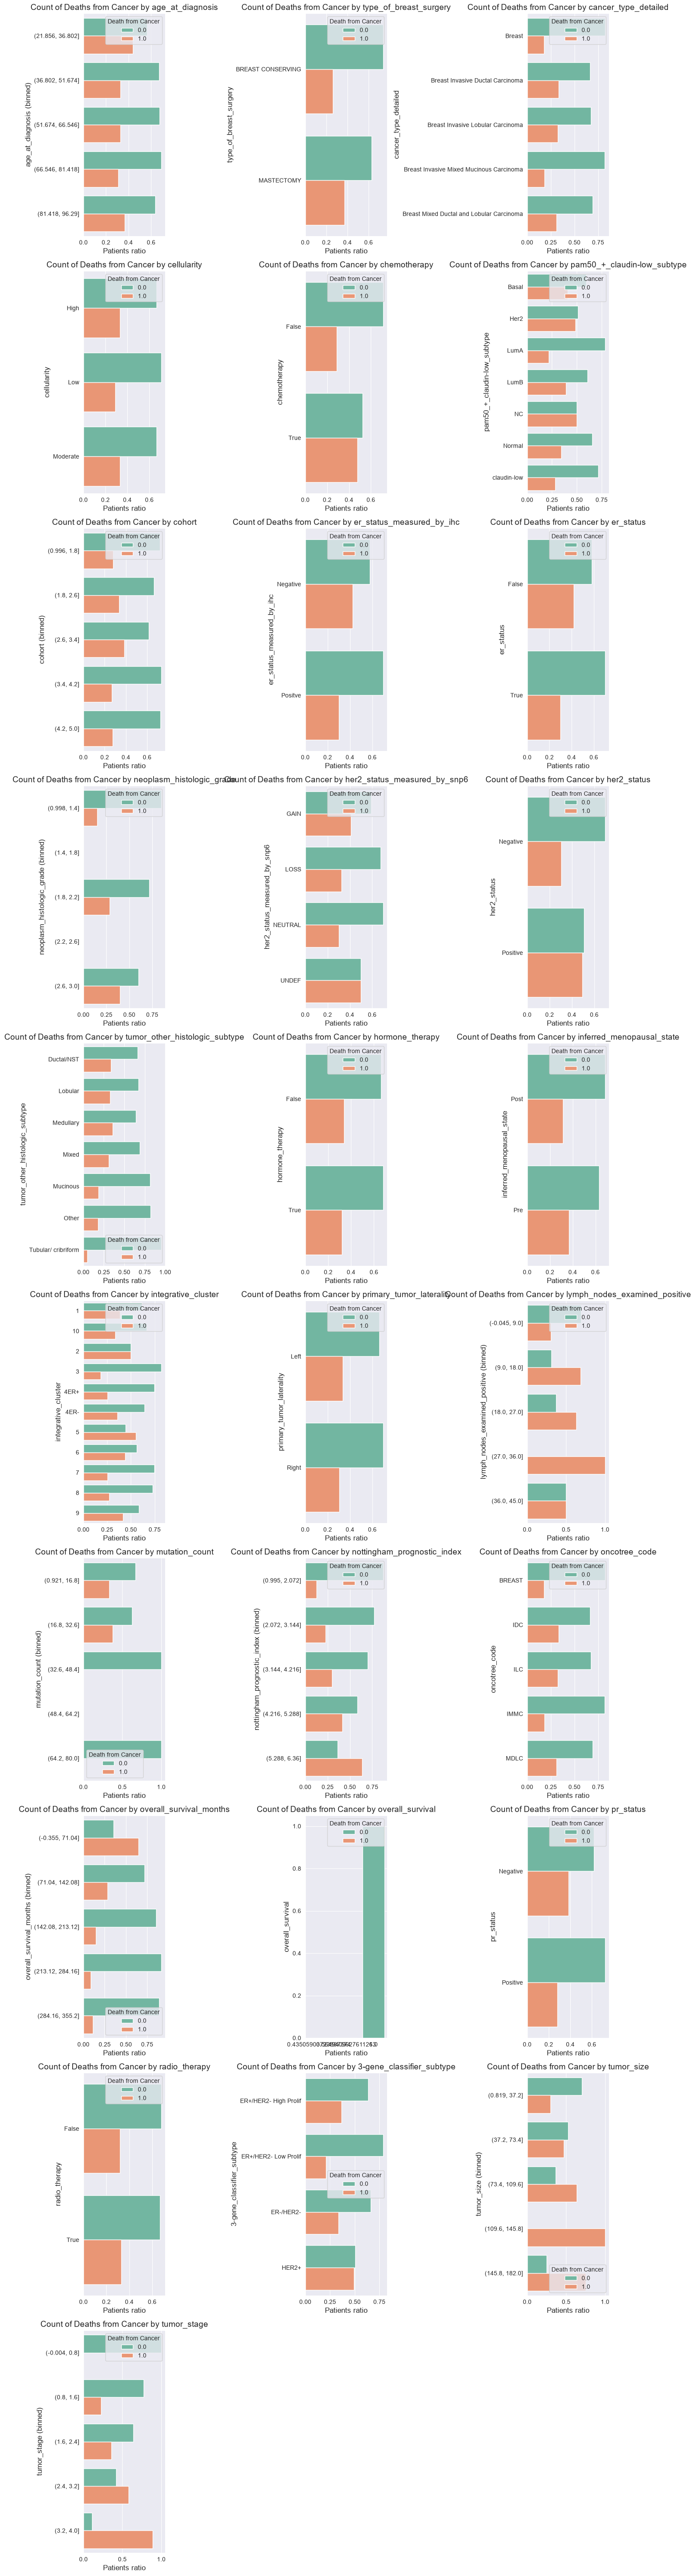

In [154]:
def plot_features_vs_target(df, cols_to_compare, target_col='death_from_cancer', num_bins=5):
    plots_per_row = 3 
    num_rows = math.ceil(len(cols_to_compare) / plots_per_row)
    
    fig, axes = plt.subplots(num_rows, plots_per_row, figsize=(14, 6 * num_rows))
    
    if len(cols_to_compare) > 1:
        axes = axes.flatten()
    else:
        axes = [axes]
        
    for i, col in enumerate(cols_to_compare):
        ax = axes[i]
        
        feature_data = df[col]
        
        is_numeric = pd.api.types.is_numeric_dtype(feature_data)
        if is_numeric and feature_data.nunique() > 2:
            feature_data = pd.cut(feature_data, bins=num_bins)
            ylabel_text = f"{col} (binned)"
        else:
            ylabel_text = col
            
        temp_df = pd.DataFrame({
            'feature': feature_data,
            target_col: df[target_col]
        })
        
        s = temp_df.groupby('feature', observed=True)[target_col].value_counts(normalize=True)\
              .rename('proportion').reset_index()
        
        sns.barplot(
            data=s, 
            x='proportion', 
            y='feature', 
            hue=target_col, 
            palette='Set2', 
            ax=ax
        )
        
        ax.set_title(f'Count of Deaths from Cancer by {col}', fontsize=14)
        ax.set_xlabel('Patients ratio', fontsize=12)
        ax.set_ylabel(ylabel_text, fontsize=12)
        ax.legend(title='Death from Cancer')
        
    for j in range(len(cols_to_compare), len(axes)):
        fig.delaxes(axes[j])
        
    plt.tight_layout()
    plt.show()


cols_to_compare = ['age_at_diagnosis', 'type_of_breast_surgery', 'cancer_type_detailed', 'cellularity', 'chemotherapy', 'pam50_+_claudin-low_subtype', 'cohort', 'er_status_measured_by_ihc', 'er_status', 'neoplasm_histologic_grade', 'her2_status_measured_by_snp6', 'her2_status', 'tumor_other_histologic_subtype', 'hormone_therapy', 'inferred_menopausal_state', 'integrative_cluster', 'primary_tumor_laterality', 'lymph_nodes_examined_positive', 'mutation_count', 'nottingham_prognostic_index', 'oncotree_code', 'overall_survival_months', 'overall_survival', 'pr_status', 'radio_therapy', '3-gene_classifier_subtype', 'tumor_size', 'tumor_stage']
plot_features_vs_target(death_df, cols_to_compare)

In [155]:
death_df = death_df.drop(columns=["er_status_measured_by_ihc", "her2_status_measured_by_snp6", "overall_survival", "overall_survival_months", "primary_tumor_laterality", "inferred_menopausal_state", "radio_therapy"] + genes + mutations)
death_df.head(10)

,patient_id,age_at_diagnosis,type_of_breast_surgery,cancer_type_detailed,cellularity,chemotherapy,pam50_+_claudin-low_subtype,cohort,er_status,neoplasm_histologic_grade,...,integrative_cluster,lymph_nodes_examined_positive,mutation_count,nottingham_prognostic_index,oncotree_code,pr_status,3-gene_classifier_subtype,tumor_size,tumor_stage,death_from_cancer
0,0,75.65,MASTECTOMY,Breast Invasive Ductal Carcinoma,NaN,False,claudin-low,1.0,True,3.0,...,4ER+,10.0,NaN,6.044,IDC,Negative,ER-/HER2-,22.0,2.0,0.0
1,2,43.19,BREAST CONSERVING,Breast Invasive Ductal Carcinoma,High,False,LumA,1.0,True,3.0,...,4ER+,0.0,2.0,4.020,IDC,Positive,ER+/HER2- High Prolif,10.0,1.0,0.0
2,5,48.87,MASTECTOMY,Breast Invasive Ductal Carcinoma,High,True,LumB,1.0,True,2.0,...,3,1.0,2.0,4.030,IDC,Positive,NaN,15.0,2.0,1.0
3,6,47.68,MASTECTOMY,Breast Mixed Ductal and Lobular Carcinoma,Moderate,True,LumB,1.0,True,2.0,...,9,3.0,1.0,4.050,MDLC,Positive,NaN,25.0,2.0,0.0
4,8,76.97,MASTECTOMY,Breast Mixed Ductal and Lobular Carcinoma,High,True,LumB,1.0,True,3.0,...,9,8.0,2.0,6.080,MDLC,Positive,ER+/HER2- High Prolif,40.0,2.0,1.0
5,10,78.77,MASTECTOMY,Breast Invasive Ductal Carcinoma,Moderate,False,LumB,1.0,True,3.0,...,7,0.0,4.0,4.062,IDC,Positive,ER+/HER2- High Prolif,31.0,4.0,1.0
6,14,56.45,BREAST CONSERVING,Breast Invasive Ductal Carcinoma,Moderate,True,LumB,1.0,True,2.0,...,3,1.0,4.0,4.020,IDC,Positive,NaN,10.0,2.0,0.0
7,22,89.08,BREAST CONSERVING,Breast Mixed Ductal and Lobular Carcinoma,Moderate,False,claudin-low,1.0,True,2.0,...,3,1.0,1.0,4.058,MDLC,Negative,NaN,29.0,2.0,0.0
8,28,86.41,BREAST CONSERVING,Breast Invasive Ductal Carcinoma,Moderate,False,LumB,1.0,True,3.0,...,9,1.0,4.0,5.032,IDC,Negative,ER+/HER2- High Prolif,16.0,2.0,0.0
9,35,84.22,MASTECTOMY,Breast Invasive Lobular Carcinoma,High,False,Her2,1.0,True,2.0,...,3,0.0,5.0,3.056,ILC,Negative,ER+/HER2- High Prolif,28.0,2.0,1.0


In [156]:
death_df.info()

<class 'pandas.DataFrame'>
Index: 1902 entries, 0 to 1903
Data columns (total 23 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   patient_id                      1902 non-null   int64  
 1   age_at_diagnosis                1902 non-null   float64
 2   type_of_breast_surgery          1880 non-null   str    
 3   cancer_type_detailed            1887 non-null   str    
 4   cellularity                     1848 non-null   str    
 5   chemotherapy                    1902 non-null   str    
 6   pam50_+_claudin-low_subtype     1902 non-null   str    
 7   cohort                          1902 non-null   float64
 8   er_status                       1902 non-null   str    
 9   neoplasm_histologic_grade       1831 non-null   float64
 10  her2_status                     1902 non-null   str    
 11  tumor_other_histologic_subtype  1887 non-null   str    
 12  hormone_therapy                 1902 non-null   st

In [157]:

death_df_tumor_stage_predicted = death_df.copy()
cols_for_imputation = ['tumor_size', 'lymph_nodes_examined_positive', 
                       'nottingham_prognostic_index', 'neoplasm_histologic_grade', 'tumor_stage']

imputer = KNNImputer(n_neighbors=5)
death_df_tumor_stage_predicted[cols_for_imputation] = imputer.fit_transform(death_df_tumor_stage_predicted[cols_for_imputation])

death_df_tumor_stage_predicted['tumor_stage'] = death_df_tumor_stage_predicted['tumor_stage'].round()
death_df_tumor_stage_predicted.info()

<class 'pandas.DataFrame'>
Index: 1902 entries, 0 to 1903
Data columns (total 23 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   patient_id                      1902 non-null   int64  
 1   age_at_diagnosis                1902 non-null   float64
 2   type_of_breast_surgery          1880 non-null   str    
 3   cancer_type_detailed            1887 non-null   str    
 4   cellularity                     1848 non-null   str    
 5   chemotherapy                    1902 non-null   str    
 6   pam50_+_claudin-low_subtype     1902 non-null   str    
 7   cohort                          1902 non-null   float64
 8   er_status                       1902 non-null   str    
 9   neoplasm_histologic_grade       1902 non-null   float64
 10  her2_status                     1902 non-null   str    
 11  tumor_other_histologic_subtype  1887 non-null   str    
 12  hormone_therapy                 1902 non-null   st

In [158]:
death_df_tumor_stage_predicted["3-gene_classifier_subtype"].value_counts()

3-gene_classifier_subtype
ER+/HER2- Low Prolif     619
ER+/HER2- High Prolif    602
ER-/HER2-                290
HER2+                    188
Name: count, dtype: int64

In [159]:
death_df_tumor_stage_predicted["er_status"].value_counts()

er_status
True     1458
False     444
Name: count, dtype: int64

In [160]:
death_df_tumor_stage_predicted["her2_status"].value_counts()

her2_status
Negative    1666
Positive     236
Name: count, dtype: int64

In [161]:
death_df_tumor_stage_predicted["pr_status"].value_counts()

pr_status
Positive    1007
Negative     895
Name: count, dtype: int64

In [162]:
death_df_tumor_stage_predicted["neoplasm_histologic_grade"].value_counts()

neoplasm_histologic_grade
3.0    926
2.0    752
1.0    200
1.2      7
1.6      5
1.8      5
1.4      3
2.4      2
2.8      2
Name: count, dtype: int64

In [163]:
death_df_tumor_stage_predicted["pam50_+_claudin-low_subtype"].value_counts()

pam50_+_claudin-low_subtype
LumA           678
LumB           461
Her2           220
Basal          199
claudin-low    198
Normal         140
NC               6
Name: count, dtype: int64

In [164]:
bool_map = {"Positive": True, "Negative": False, "True": True, "False": False}
death_df_tumor_stage_predicted["her2_status"] = death_df_tumor_stage_predicted["her2_status"].map(bool_map)
death_df_tumor_stage_predicted["pr_status"] = death_df_tumor_stage_predicted["pr_status"].map(bool_map)
death_df_tumor_stage_predicted["er_status"] = death_df_tumor_stage_predicted["er_status"].map(bool_map)
death_df_tumor_stage_predicted["chemotherapy"] = death_df_tumor_stage_predicted["chemotherapy"].map(bool_map)
death_df_tumor_stage_predicted["hormone_therapy"] = death_df_tumor_stage_predicted["hormone_therapy"].map(bool_map)
gene_classifier_subtype_df = death_df_tumor_stage_predicted.copy()
gene_classifier_subtype_df.head(10)

,patient_id,age_at_diagnosis,type_of_breast_surgery,cancer_type_detailed,cellularity,chemotherapy,pam50_+_claudin-low_subtype,cohort,er_status,neoplasm_histologic_grade,...,integrative_cluster,lymph_nodes_examined_positive,mutation_count,nottingham_prognostic_index,oncotree_code,pr_status,3-gene_classifier_subtype,tumor_size,tumor_stage,death_from_cancer
0,0,75.65,MASTECTOMY,Breast Invasive Ductal Carcinoma,NaN,False,claudin-low,1.0,True,3.0,...,4ER+,10.0,NaN,6.044,IDC,False,ER-/HER2-,22.0,2.0,0.0
1,2,43.19,BREAST CONSERVING,Breast Invasive Ductal Carcinoma,High,False,LumA,1.0,True,3.0,...,4ER+,0.0,2.0,4.020,IDC,True,ER+/HER2- High Prolif,10.0,1.0,0.0
2,5,48.87,MASTECTOMY,Breast Invasive Ductal Carcinoma,High,True,LumB,1.0,True,2.0,...,3,1.0,2.0,4.030,IDC,True,NaN,15.0,2.0,1.0
3,6,47.68,MASTECTOMY,Breast Mixed Ductal and Lobular Carcinoma,Moderate,True,LumB,1.0,True,2.0,...,9,3.0,1.0,4.050,MDLC,True,NaN,25.0,2.0,0.0
4,8,76.97,MASTECTOMY,Breast Mixed Ductal and Lobular Carcinoma,High,True,LumB,1.0,True,3.0,...,9,8.0,2.0,6.080,MDLC,True,ER+/HER2- High Prolif,40.0,2.0,1.0
5,10,78.77,MASTECTOMY,Breast Invasive Ductal Carcinoma,Moderate,False,LumB,1.0,True,3.0,...,7,0.0,4.0,4.062,IDC,True,ER+/HER2- High Prolif,31.0,4.0,1.0
6,14,56.45,BREAST CONSERVING,Breast Invasive Ductal Carcinoma,Moderate,True,LumB,1.0,True,2.0,...,3,1.0,4.0,4.020,IDC,True,NaN,10.0,2.0,0.0
7,22,89.08,BREAST CONSERVING,Breast Mixed Ductal and Lobular Carcinoma,Moderate,False,claudin-low,1.0,True,2.0,...,3,1.0,1.0,4.058,MDLC,False,NaN,29.0,2.0,0.0
8,28,86.41,BREAST CONSERVING,Breast Invasive Ductal Carcinoma,Moderate,False,LumB,1.0,True,3.0,...,9,1.0,4.0,5.032,IDC,False,ER+/HER2- High Prolif,16.0,2.0,0.0
9,35,84.22,MASTECTOMY,Breast Invasive Lobular Carcinoma,High,False,Her2,1.0,True,2.0,...,3,0.0,5.0,3.056,ILC,False,ER+/HER2- High Prolif,28.0,2.0,1.0


In [165]:
gene_classifier_subtype_df = pd.get_dummies(gene_classifier_subtype_df, columns=["pam50_+_claudin-low_subtype"])
gene_classifier_subtype_df.info()

<class 'pandas.DataFrame'>
Index: 1902 entries, 0 to 1903
Data columns (total 29 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   patient_id                               1902 non-null   int64  
 1   age_at_diagnosis                         1902 non-null   float64
 2   type_of_breast_surgery                   1880 non-null   str    
 3   cancer_type_detailed                     1887 non-null   str    
 4   cellularity                              1848 non-null   str    
 5   chemotherapy                             1902 non-null   bool   
 6   cohort                                   1902 non-null   float64
 7   er_status                                1902 non-null   bool   
 8   neoplasm_histologic_grade                1902 non-null   float64
 9   her2_status                              1902 non-null   bool   
 10  tumor_other_histologic_subtype           1887 non-null   str    

In [166]:
features_for_imputation = [
    'er_status', 
    'her2_status', 
    'pr_status', 
    'neoplasm_histologic_grade',
    'pam50_+_claudin-low_subtype_Basal', 
    'pam50_+_claudin-low_subtype_Her2',
    'pam50_+_claudin-low_subtype_LumA', 
    'pam50_+_claudin-low_subtype_LumB',
    'pam50_+_claudin-low_subtype_NC', 
    'pam50_+_claudin-low_subtype_Normal',
    'pam50_+_claudin-low_subtype_claudin-low'
]

target_col = '3-gene_classifier_subtype'

known_data = gene_classifier_subtype_df[gene_classifier_subtype_df[target_col].notna()]
missing_data = gene_classifier_subtype_df[gene_classifier_subtype_df[target_col].isna()]

rf_imputer = RandomForestClassifier(n_estimators=100, random_state=42)

rf_imputer.fit(known_data[features_for_imputation], known_data[target_col])

predicted_values = rf_imputer.predict(missing_data[features_for_imputation])

gene_classifier_subtype_df.loc[gene_classifier_subtype_df[target_col].isna(), target_col] = predicted_values

gene_classifier_subtype_df[target_col].info()

<class 'pandas.Series'>
Index: 1902 entries, 0 to 1903
Series name: 3-gene_classifier_subtype
Non-Null Count  Dtype
--------------  -----
1902 non-null   str  
dtypes: str(1)
memory usage: 60.8 KB


In [167]:
gene_classifier_subtype_df[target_col].value_counts()

3-gene_classifier_subtype
ER+/HER2- Low Prolif     685
ER+/HER2- High Prolif    666
ER-/HER2-                347
HER2+                    204
Name: count, dtype: int64

In [168]:
final_df = gene_classifier_subtype_df.dropna(axis=0, how='any')
final_df.info()

<class 'pandas.DataFrame'>
Index: 1775 entries, 1 to 1903
Data columns (total 29 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   patient_id                               1775 non-null   int64  
 1   age_at_diagnosis                         1775 non-null   float64
 2   type_of_breast_surgery                   1775 non-null   str    
 3   cancer_type_detailed                     1775 non-null   str    
 4   cellularity                              1775 non-null   str    
 5   chemotherapy                             1775 non-null   bool   
 6   cohort                                   1775 non-null   float64
 7   er_status                                1775 non-null   bool   
 8   neoplasm_histologic_grade                1775 non-null   float64
 9   her2_status                              1775 non-null   bool   
 10  tumor_other_histologic_subtype           1775 non-null   str    

In [169]:
final_df = pd.get_dummies(final_df, columns=["type_of_breast_surgery", "cancer_type_detailed", "tumor_other_histologic_subtype", "oncotree_code", "integrative_cluster", "3-gene_classifier_subtype"])

In [170]:
final_df["cellularity"] = final_df["cellularity"].map({"Low": 0, "Moderate": 1, "High": 2})

In [171]:
train_set, test_set = train_test_split(final_df.drop("patient_id", axis=1), test_size=0.2, random_state=42)
X_train = train_set.drop("death_from_cancer", axis=1)
y_train = train_set["death_from_cancer"]
X_test = test_set.drop("death_from_cancer", axis=1)
y_test = test_set["death_from_cancer"]
X_train.describe()

,age_at_diagnosis,cellularity,cohort,neoplasm_histologic_grade,lymph_nodes_examined_positive,mutation_count,nottingham_prognostic_index,tumor_size,tumor_stage
count,1420.000000,1420.000000,1420.000000,1420.000000,1420.000000,1420.000000,1420.000000,1420.000000,1420.000000
mean,61.366148,1.409859,2.731690,2.375352,1.973944,5.686620,4.037281,26.423938,1.775352
std,12.921504,0.670249,1.229418,0.664735,3.995949,3.577152,1.125732,15.883356,0.607295
min,21.930000,0.000000,1.000000,1.000000,0.000000,1.000000,1.020000,1.000000,0.000000
25%,51.555000,1.000000,2.000000,2.000000,0.000000,3.000000,3.050000,17.000000,1.000000
50%,62.305000,2.000000,3.000000,2.000000,0.000000,5.000000,4.044000,23.000000,2.000000
75%,70.902500,2.000000,3.000000,3.000000,2.000000,7.000000,5.040000,30.000000,2.000000
max,92.140000,2.000000,5.000000,3.000000,45.000000,40.000000,6.360000,182.000000,4.000000


In [172]:
final_df.columns

Index(['patient_id', 'age_at_diagnosis', 'cellularity', 'chemotherapy',
       'cohort', 'er_status', 'neoplasm_histologic_grade', 'her2_status',
       'hormone_therapy', 'lymph_nodes_examined_positive', 'mutation_count',
       'nottingham_prognostic_index', 'pr_status', 'tumor_size', 'tumor_stage',
       'death_from_cancer', 'pam50_+_claudin-low_subtype_Basal',
       'pam50_+_claudin-low_subtype_Her2', 'pam50_+_claudin-low_subtype_LumA',
       'pam50_+_claudin-low_subtype_LumB', 'pam50_+_claudin-low_subtype_NC',
       'pam50_+_claudin-low_subtype_Normal',
       'pam50_+_claudin-low_subtype_claudin-low',
       'type_of_breast_surgery_BREAST CONSERVING',
       'type_of_breast_surgery_MASTECTOMY', 'cancer_type_detailed_Breast',
       'cancer_type_detailed_Breast Invasive Ductal Carcinoma',
       'cancer_type_detailed_Breast Invasive Lobular Carcinoma',
       'cancer_type_detailed_Breast Invasive Mixed Mucinous Carcinoma',
       'cancer_type_detailed_Breast Mixed Ductal and L

In [173]:
scaler = MinMaxScaler().set_output(transform="pandas")
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [174]:
death_models_2 = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=100, random_state=42),
}

metrics_report = []

for model_name, model in death_models_2.items():
    start_time = time.time()
    
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    
    train_time = time.time() - start_time
    
    metrics_report.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision (CT)": precision_score(y_test, y_pred),
        "Recall (CT)": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "ROC AUC": roc_auc_score(y_test, y_prob),
        "Time (sec)": round(train_time, 2)
    })

report_df = pd.DataFrame(metrics_report)

report_df = report_df.sort_values(by="ROC AUC", ascending=False).reset_index(drop=True)

print(report_df.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

              Model  Accuracy  Precision (CT)  Recall (CT)  F1 Score  ROC AUC  Time (sec)
Logistic Regression    0.7127          0.5902       0.3186    0.4138   0.6891      0.0200
  Gradient Boosting    0.6901          0.5172       0.3982    0.4500   0.6810      0.3900
      Random Forest    0.6676          0.4648       0.2920    0.3587   0.6678      0.2400


In [175]:
importances = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': death_models_2["Random Forest"].feature_importances_
})

importances = importances.sort_values(by='Importance', ascending=False)
importances.head(10)

,Feature,Importance
10,nottingham_prognostic_index,0.127844
0,age_at_diagnosis,0.111283
12,tumor_size,0.094778
9,mutation_count,0.085149
8,lymph_nodes_examined_positive,0.070933
3,cohort,0.050473
1,cellularity,0.031597
13,tumor_stage,0.028233
5,neoplasm_histologic_grade,0.024742
16,pam50_+_claudin-low_subtype_LumA,0.021181


In [176]:
importances = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': permutation_importance(death_models_2["Logistic Regression"], X_train, y_train)['importances_mean']
})
importances = importances.sort_values(by='Importance', ascending=False)
importances.head(10)

,Feature,Importance
10,nottingham_prognostic_index,0.018169
41,integrative_cluster_10,0.013944
46,integrative_cluster_5,0.010282
16,pam50_+_claudin-low_subtype_LumA,0.008169
8,lymph_nodes_examined_positive,0.007746
53,3-gene_classifier_subtype_ER-/HER2-,0.006479
42,integrative_cluster_2,0.006338
13,tumor_stage,0.006056
11,pr_status,0.004930
54,3-gene_classifier_subtype_HER2+,0.003099


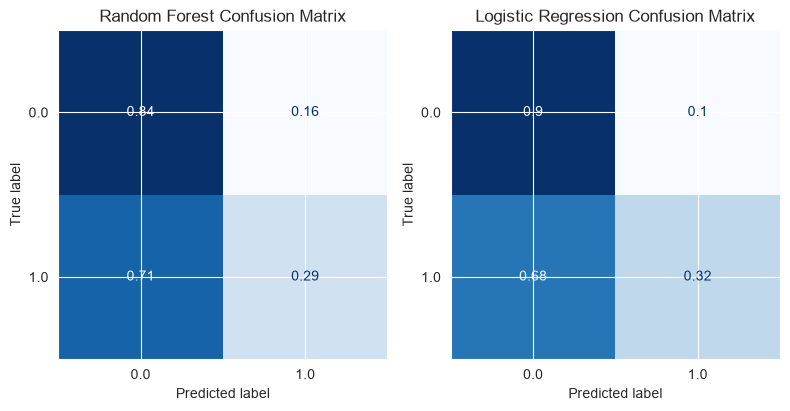

In [177]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(8, 5))
ConfusionMatrixDisplay.from_estimator(
    death_models_2["Random Forest"], X_test, y_test, 
    cmap=plt.cm.Blues, 
    colorbar=False,
    ax=axes[0],
    normalize="true"
)
ConfusionMatrixDisplay.from_estimator(
    death_models_2["Logistic Regression"], X_test, y_test, 
    cmap=plt.cm.Blues, 
    colorbar=False,
    ax=axes[1],
    normalize="true"
)
axes[0].set_title('Random Forest Confusion Matrix')
axes[1].set_title('Logistic Regression Confusion Matrix')
plt.tight_layout()
plt.show()

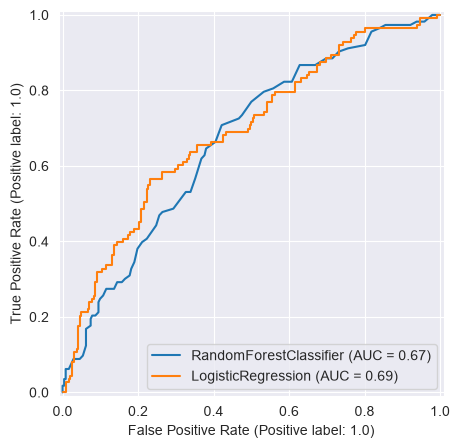

In [178]:
fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(8, 5))
RocCurveDisplay.from_estimator(death_models_2["Random Forest"], X_test, y_test, ax=axes)
RocCurveDisplay.from_estimator(death_models_2["Logistic Regression"], X_test, y_test, ax=axes)
plt.show()

## Analytical Conclusion: Model Performance & Biological Interpretation

In this study, classical machine learning algorithms were evaluated across two fundamentally different feature spaces: a **high-dimensional transcriptomic space** (489 mRNA z-scores) and a **low-dimensional clinical space**. 

Given the moderate class imbalance in the target variable `death_from_cancer` (~67% alive vs. 33% deceased), **Accuracy proved to be a profoundly misleading metric.** Model performance must be interpreted strictly through the lens of **$ROC-AUC$** (class separation capability) and the **$F_1$-score** (the harmonic mean of Precision and Recall).

---

### 1. The Clinical Feature Space: The Triumph of Linearity
**Winner: Logistic Regression** ($F_1 = 0.4138$ | $ROC-AUC = 0.6891$)

* **The Theoretical Justification:** Clinical attributes (such as *Tumor Stage*, *Tumor Size*, and the *Nottingham Prognostic Index*) were historically engineered by oncologists to maintain a direct, monotonic, linear relationship with patient mortality. Logistic Regression excels in this low-dimensional, linear regime. 
* **Why Ensembles failed to win:** Tree-based models (Random Forest, Gradient Boosting) over-engineer the problem. By attempting to draw orthogonal, non-linear decision boundaries across simple linear risk gradients, they become prone to local variance, resulting in inferior generalization on the test set.

---

### 2. The Gene Expression Space: The High-Dimensional Trap
**Winner by separation: Gradient Boosting** ($ROC-AUC = 0.7049$)  
**Winner by balance: Logistic Regression** ($F_1 = 0.4186$)

* **The Fall of Random Forest:** Despite achieving the highest "Accuracy" ($0.7139$), Random Forest suffered a catastrophic failure, yielding a **Recall of only $0.0991$** (identifying less than 10% of deceased patients). In a high-dimensional, noisy space with an imbalanced target, standard bagging struggles to find robust splits for the minority class, effectively causing the ensemble to default its votes to the majority class.
* **The Power of Boosting:** Gradient Boosting achieved the top $ROC-AUC$ because its sequential nature—where each tree corrects the residuals of the previous one—allows it to capture complex, non-linear gene-gene interactions (epistasis) hidden within the transcriptomic noise.
* **The Stability of L2 Regularization:** Logistic Regression maintained the highest $F_1$-score because its underlying $L_2$ penalty mathematically suppressed the background noise of 300+ irrelevant genes, forcing the model to anchor its weights strictly to the strongest linear transcriptomic survival markers.

---

### 3. Key Takeaways for Clinical ML

1. **Macroscopic Pathology > Microscopic Transcription:** Baseline mRNA expression alone is an inherently weaker predictor of breast cancer mortality than physical tumor staging. What the cancer *has already done* to the tissue (Node involvement, NPI) dictates 10-year survival far more heavily than its baseline transcription profile.
2. **Beware the "Lazy Tree":** Ensembles cannot be trusted blindly on raw biological data. Without explicit class-weighting (`class_weight='balanced'`) or synthetic oversampling (SMOTE), Random Forest will exploit class imbalance to optimize global accuracy at the expense of clinical utility.
3. **Domain dictates Architecture:** Low-dimensional, human-engineered medical scores call for linear, highly interpretable models. High-dimensional, interacting biological networks require sequential boosting or deep learning representations.